## Silver Layer: Data Cleaning and Transformation
cleaned and transformed data, ready for analysis and modeling

In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import libraries

In [49]:
import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pandas import DataFrame
# import pandera as pa
# from typing import Iterable

import sys
from pathlib import Path
project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

Read data from bronze layer

In [50]:
df_bronze = pd.read_parquet('../../data/dev/raw/production_time_bronze.parquet')
df_bronze.info()
df_bronze.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4154 entries, 0 to 4153
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   op_w          4154 non-null   float64 
 1   op_l          4154 non-null   float64 
 2   wire_dia      4154 non-null   float64 
 3   op_align      549 non-null    category
 4   qty           4154 non-null   int64   
 5   mesh_fl       4154 non-null   float64 
 6   mesh_sp       4154 non-null   float64 
 7   batch_width   4154 non-null   float64 
 8   batch_length  4154 non-null   float64 
 9   process_time  4154 non-null   float64 
 10  stand_type    4154 non-null   category
dtypes: category(2), float64(8), int64(1)
memory usage: 300.7 KB


,op_w,op_l,wire_dia,op_align,qty,mesh_fl,mesh_sp,batch_width,batch_length,process_time,stand_type
0,2.0,2.0,1.2,NaN,3,1050.0,1805.0,1050.0,6300.0,390.0,KROSNO I
1,2.0,2.0,1.2,NaN,8,1020.0,2715.0,1020.0,21700.0,660.0,KROSNO I
2,1.5,70.0,1.3,A,1,1515.0,2160.0,1515.0,3000.0,240.0,KROSNO I
3,4.0,4.0,1.8,NaN,1,1390.0,2440.0,1390.0,3150.0,150.0,KROSNO I
4,2.5,87.0,1.4,A,15,1340.0,1825.0,1340.0,28200.0,750.0,KROSNO I



---
### 1. Cleaning and Imputation

In [51]:
from notebooks.utils.cleaning.data_cleaner import DataCleaner

* Clean and impute missing values in 'op_align' column

In [52]:
print(df_bronze['op_align'].value_counts())

op_align
A      475
B       71
a        2
ST1      1
Name: count, dtype: int64


In [53]:
df_bronze = DataCleaner.clean_op_align(df_bronze)

print(df_bronze['op_align'].value_counts())

op_align
S    3605
A     477
B      71
Name: count, dtype: int64


* Rename columns for consistency and ease of use in 'stand_type'

In [54]:
print(df_bronze['stand_type'].unique().tolist())

['KROSNO I', 'KROSNO II', 'KROSNO III', 'KROSNO IV', 'KROSNO V']


In [55]:
df_bronze = DataCleaner.rename_stand_type(df_bronze)

print(df_bronze['stand_type'].unique().tolist())

print(df_bronze['stand_type'].dtype)

['A', 'B', 'C', 'D', 'E']
category



* Check for non-numeric values in numeric columns

In [56]:
numeric_cols = ['op_w', 'op_l', 'wire_dia', 'mesh_fl', 'mesh_sp', 'batch_width', 'batch_length', 'process_time', 'qty']
nn_found = []
for col in numeric_cols:
    nn = df_bronze[df_bronze[col].isna()]
    if not nn.empty:
        nn_found.append((col, len(nn)))
if not nn_found:
    print("\nNo non-numeric values found in the specified numeric columns.")
else:
    print("\nNon-numeric values found in the following columns:")
    for col, count in nn_found:
        print(f"- {col}: {count} non-numeric values")


No non-numeric values found in the specified numeric columns.



* cleaning for 'op_w' and 'op_l' columns: drop invalid values (wrong length and width with square opening type)

In [57]:
col_names = ['op_w', 'op_l', 'op_align']
invalid_op_mask = (df_bronze['op_align'].isin(['S'])) & (df_bronze['op_w'] != df_bronze['op_l'])

print(f"\nNumber of invalid rows based on 'op_align' and 'op_w'/'op_l': {invalid_op_mask.sum()}\n")
print(df_bronze[invalid_op_mask][col_names].head(5), '\n...')


Number of invalid rows based on 'op_align' and 'op_w'/'op_l': 43

     op_w   op_l op_align
54    5.0  250.0        S
110   5.0    2.0        S
206   2.8   70.0        S
209   2.5   90.0        S
211   2.5    8.5        S 
...


In [58]:
print(f"\nData shape before removing invalid rows: {df_bronze.shape}")

df_bronze = DataCleaner.drop_invalid_op(df_bronze)

print(f"Data shape after removing invalid rows: {df_bronze.shape}")


Data shape before removing invalid rows: (4153, 11)
Data shape after removing invalid rows: (4110, 11)


In [59]:
print("\nMissing values in numeric columns after cleaning:")

print(df_bronze[numeric_cols].isna().sum())


Missing values in numeric columns after cleaning:
op_w            0
op_l            0
wire_dia        0
mesh_fl         0
mesh_sp         0
batch_width     0
batch_length    0
process_time    0
qty             0
dtype: int64


Summary statistics


---
### 2. Deduplication

In [60]:
# deduplication
initial_shape = df_bronze.shape
df_bronze = df_bronze.drop_duplicates()
final_shape = df_bronze.shape
print(f"Removed {initial_shape[0] - final_shape[0]} duplicate rows")

Removed 70 duplicate rows



---
### 3. Outliers handling: Domain-based filtering
- thresholding based on domain knowledge and visualizations (box plots, histograms)

#### 3.1 Basic statistics
- summary statistics (mean, median, std, min, max) for numeric columns
- value counts and proportions for categorical columns

In [61]:
from notebooks.utils.cleaning.statistics import StatisticsEDA

StatisticsEDA.statistics(df_bronze)

### Summary statistics for numeric columns

,count,mean,std,min,25%,50%,75%,max
op_w,4040.0,30.38,22.76,1.50,14.0,25.0,40.00,150.0
op_l,4040.0,41.03,53.70,1.50,18.0,30.0,50.00,2550.0
wire_dia,4040.0,6.04,2.85,1.00,4.0,5.5,8.00,40.0
qty,4040.0,3.05,3.32,1.00,1.0,2.0,4.00,68.0
mesh_fl,4040.0,1279.19,391.79,100.00,1050.0,1250.0,1486.25,15435.0
mesh_sp,4040.0,1962.45,1611.02,10.00,1500.0,1670.0,2200.00,52000.0
batch_width,4040.0,1281.44,490.48,100.00,1050.0,1240.0,1480.00,14200.0
batch_length,4040.0,6258.61,6142.90,6.80,3300.0,4600.0,6700.00,102000.0
process_time,4040.0,103.15,103.18,0.45,60.0,80.0,110.00,2100.0


### Summary statistics for categorical columns

,count,unique,top,freq
op_align,4040,3,S,3498
stand_type,4040,5,B,1975


outliers detected by domain knowledge:
- opening length distribution (2550 is definately outlier), 
- same wit wire diameter 40, 
- mesh_fl = 15435 is also impossible 
- and mesh_sp 52000, 
- batch_width 14200. 

suspicious to investigate:
- batch_length 102000
- process_time 2100

#### 3.2 Domain knowledge-based outliers detection
- define domain-specific cutoffs for numeric features based on engineering knowledge and visualizations

In [62]:
from notebooks.utils.cleaning.domain_outliers import DomainOutliers

# cutoff for outliers based on DOMAIN knowledge
domain_cutoffs = {
    'op_w': (0, 400),
    'op_l': (0, 400),
    'wire_dia': (0, 15),
    'mesh_fl': (0, 2500),
    'batch_width': (0, 2500)
}

# create an instance of DomainOutliers with the defined cutoffs
domain_outliers = DomainOutliers(domain_cutoffs)

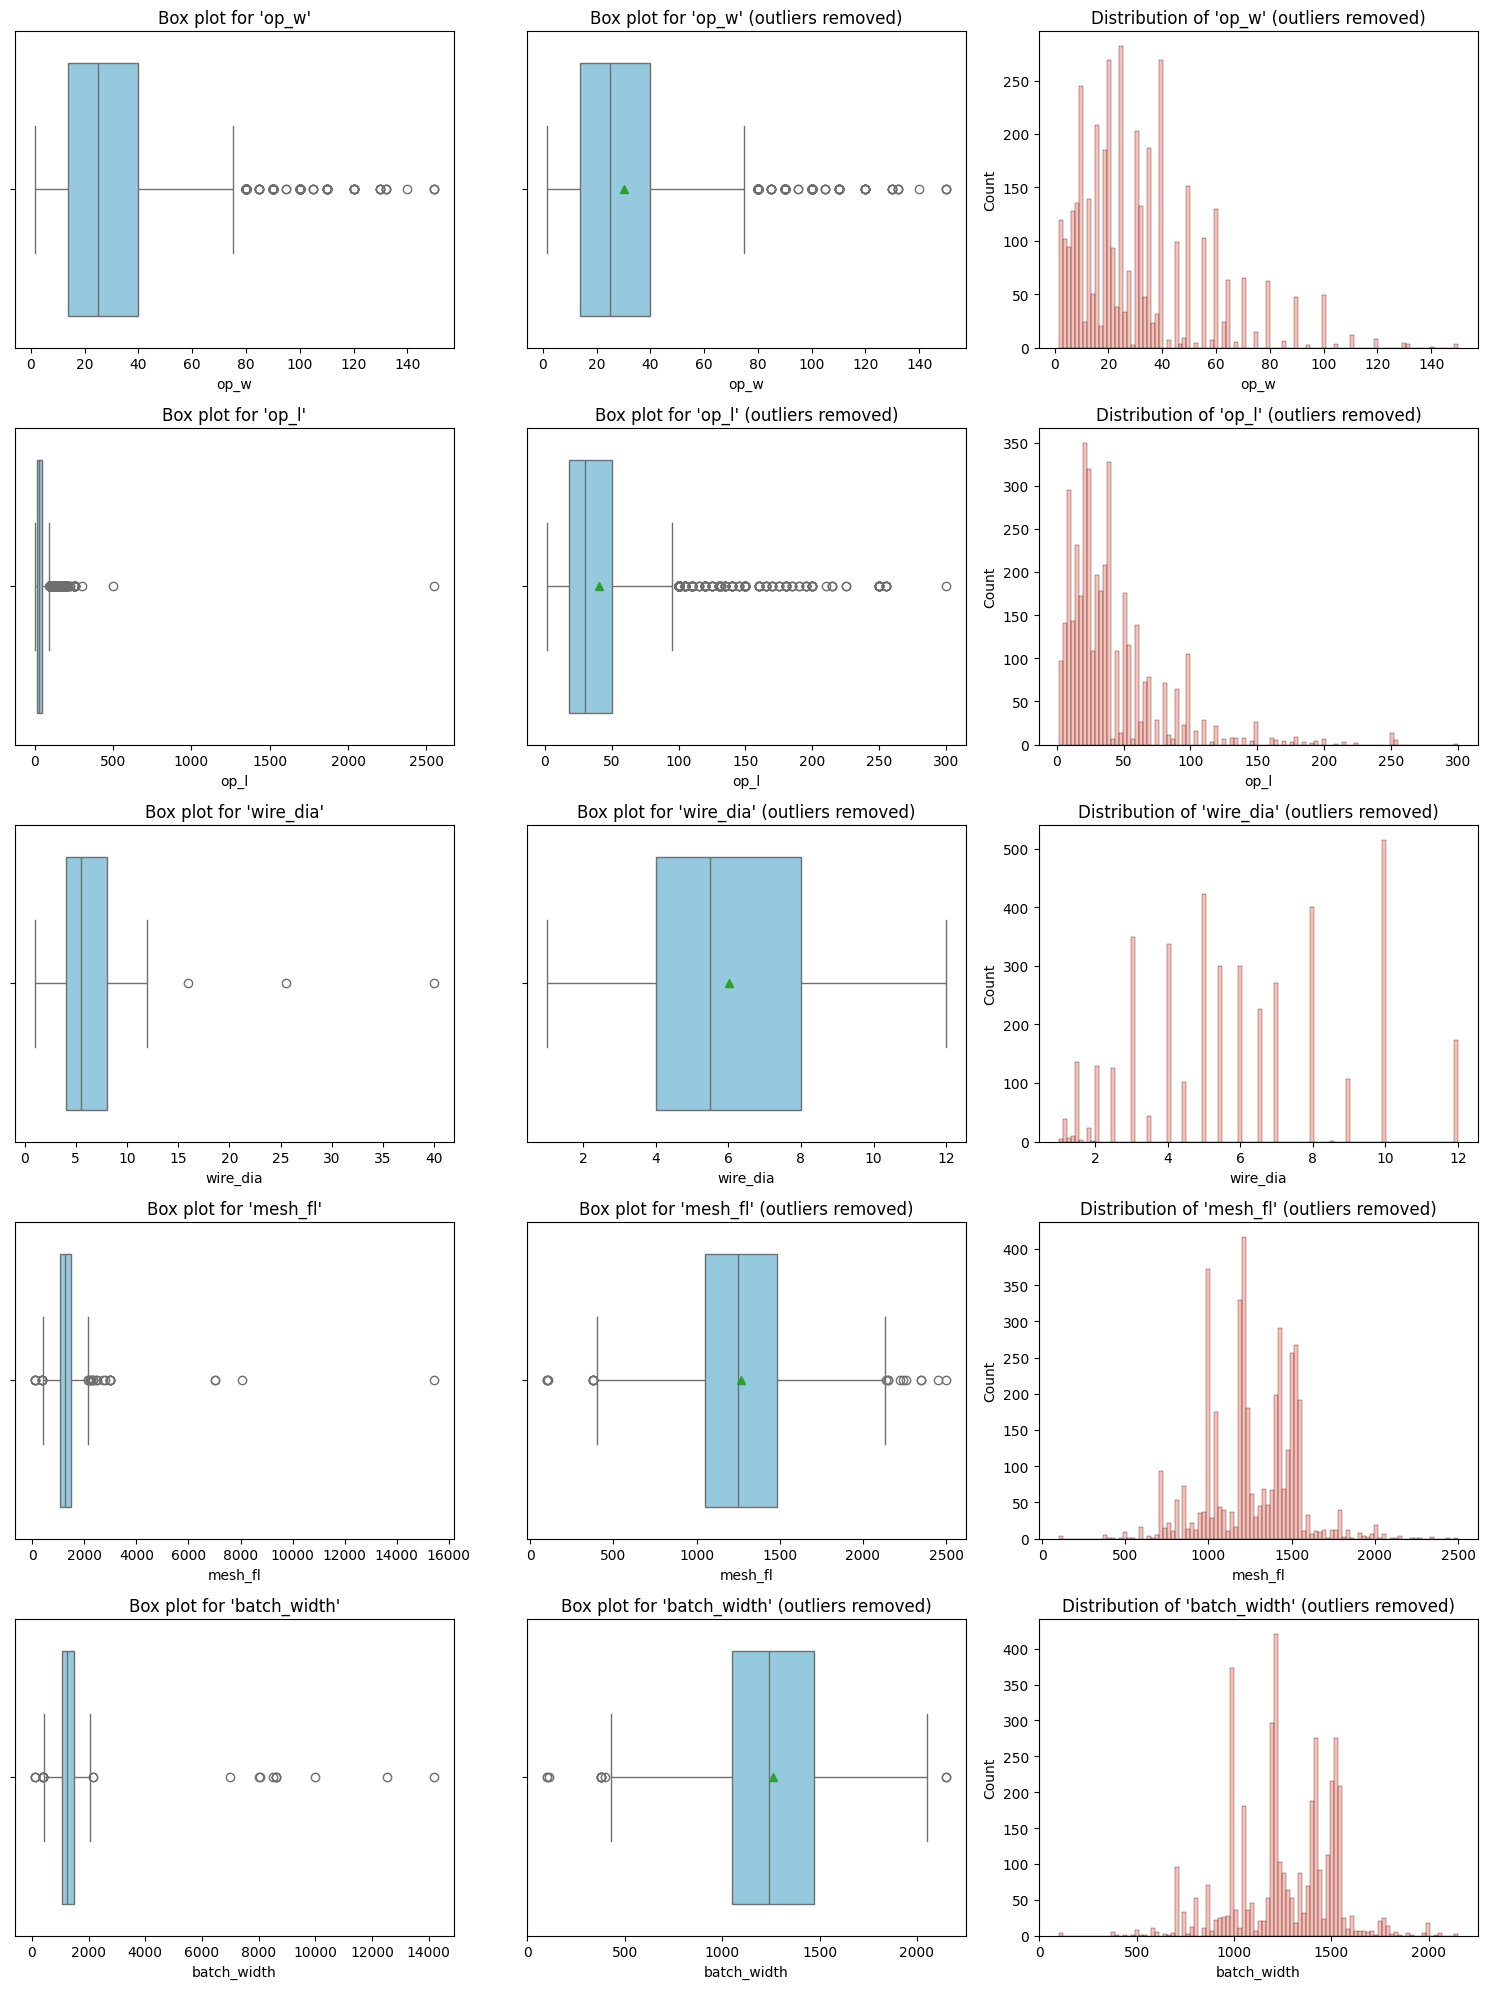

In [63]:
# visualize the impact of different cutoff values on outlier detection
domain_outliers.plot_cutoff_impact(df_bronze)

In [64]:
df_bronze = domain_outliers.filter(df_bronze)

domain_outliers.get_summary()

,cutoff range,initial count,removed,% removed
op_w,"(0, 400)",4040,0,0.0
op_l,"(0, 400)",4040,2,0.05
wire_dia,"(0, 15)",4040,3,0.07
mesh_fl,"(0, 2500)",4040,11,0.27
batch_width,"(0, 2500)",4040,10,0.25


#### 3.3 Cross-feature analysis for outlier detection
- detect outliers based on relationships between features (e.g., batch_length vs. mesh_sp length multiplied by quantity) and domain-based rules.


,op_w,op_l,wire_dia,op_align,qty,mesh_fl,mesh_sp,batch_width,batch_length,process_time,stand_type
3681,30.0,30.0,3.0,S,26,1000.0,2000.0,1000.0,54000.0,225.0,D
2404,30.0,30.0,3.0,S,26,1000.0,2000.0,1000.0,54000.0,225.0,C
371,58.0,58.0,9.0,S,24,1020.0,2370.0,1020.0,58500.0,400.0,B
3446,30.0,30.0,3.0,S,3,1000.0,20.0,100.0,61000.0,200.0,C
3242,15.0,15.0,2.0,S,68,1430.0,1470.0,1430.0,102000.0,600.0,C


### Distribution of 'batch_length' with and without log scale

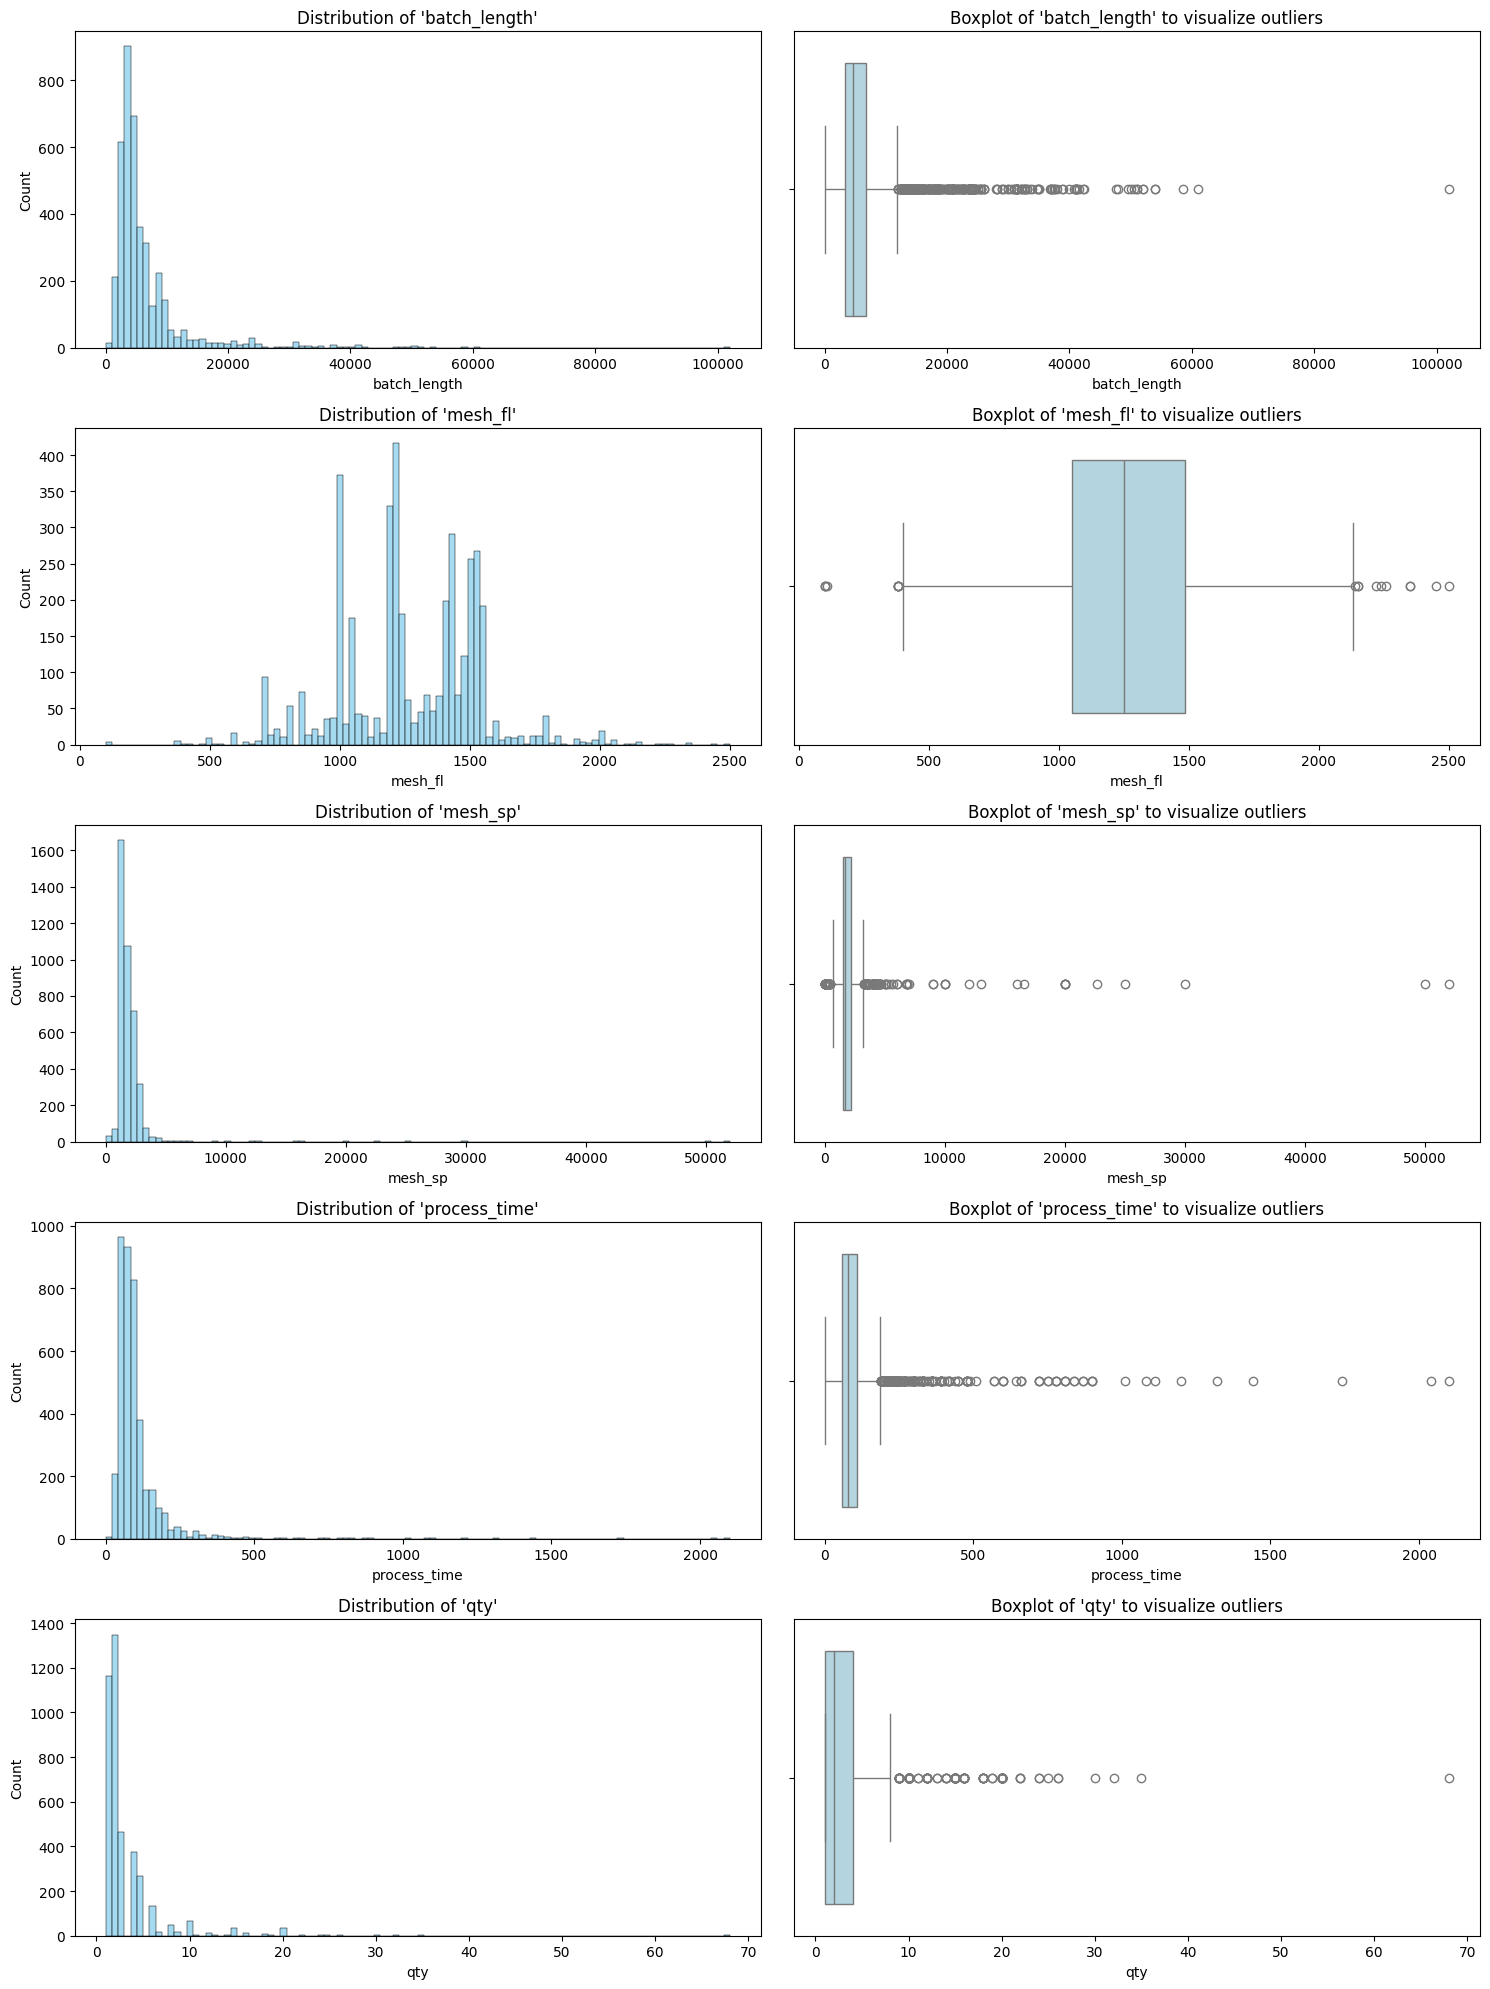

In [65]:
# Display
from IPython.display import display, Markdown

display(df_bronze.sort_values(by='batch_length').tail(5))

# Plot the distribution of batch_length to see if there are any other suspicious values
display(Markdown("### Distribution of 'batch_length' with and without log scale"))

from notebooks.utils.cleaning.visualization import Visualization
Visualization.plot_distributions(df_bronze, column_names=['batch_length', 'mesh_fl', 'mesh_sp', 'process_time', 'qty'])

Some of extreme values here aren't outliers, but rather rare cases of big orders, so we will keep them in the dataset. What we can do is to perform cross-feature validation of batch_length outliers with other relevant features to confirm if they are indeed big orders by checking if they have large batch_length, mesh_sp, and quantity values that would be consistent with a big order. If they do, we can confidently keep them in the dataset as valid data points representing rare but real scenarios.


Picking proper minimum batch length threshold for cross-feature analysis in combination with batch length deviation tolerance is very sensitive and should be done carefully based on domain knowledge to avoid misclassifying valid rows as invalid data. Each batch length is measured with changeover material allowance needed for mounting the material on the production line and it slightly varies based on the production stand, manufacturing team and other factors. Therefore I've set single approximate allowance based on domain specifics and experience and introduced slightly more generous deviation tolerance to approve more rows as valid if they are close enough (10% deviation tolerance on whole batch length). This approach captures all unexpected waste and imprecision in the production process, which happens quite often, especially in dynamic nature of High Variance Low Volume type of production like in this case.

In [66]:
from notebooks.utils.cleaning.cross_feature_analysis import CrossFeatureAnalysis

# Create an instance of CrossFeatureAnalysis with custom configuration
config = {
    'mat_allowance':    600, # min 600 mm allowance for material mount on batch length (300 mm on each side)
    'min_batch_th':     3000, # threshold for batch length to investigate (lowered from 20000 to 3000 to capture more potential outliers for analysis)
    'batchl_dev_tol':   0.1 # 10% generous threshold due to imprecision in production process and waste allowance
}

cross_feature_analysis = CrossFeatureAnalysis(config)

In [67]:
df_silver_clean = cross_feature_analysis.drop_invalid_batch_length(df_bronze)

cross_feature_analysis.get_summary()

,Value
min batch_length analysis threshold,3000 mm
batch_length deviation tolerance,10.0 %
material c/o allowance,600 mm
total rows,4016
rows analyzed,3180
invalid rows detected,153
total dropout,3.81 %


In [68]:
cross_feature_analysis.get_stats_table()

,batch_length,batch_width,qty,mesh_sp,mesh_fl,calculated_batch_length,length_diff,length_diff_percentage
2853,50500.0,1510.0,30,50000.0,1510.0,1500600.0,-1450100.0,28.71
1839,5000.0,1000.0,13,1490.0,1000.0,19970.0,-14970.0,2.99
2220,5100.0,1450.0,9,1500.0,1450.0,14100.0,-9000.0,1.76
2550,12600.0,1190.0,22,1540.0,1190.0,34480.0,-21880.0,1.74
1819,3800.0,1430.0,6,1500.0,1430.0,9600.0,-5800.0,1.53
1425,3500.0,1345.0,4,1645.0,1345.0,7180.0,-3680.0,1.05
3446,61000.0,100.0,3,20.0,1000.0,660.0,60340.0,0.99
99,52000.0,1000.0,5,10.0,1000.0,650.0,51350.0,0.99
3964,51000.0,2000.0,1,50.0,2000.0,650.0,50350.0,0.99
4096,51000.0,2000.0,2,25.0,2000.0,650.0,50350.0,0.99


In [69]:
cross_feature_analysis.get_stats_summary()

,count,mean,std,min,25%,50%,75%,max
batch_length,153.0,9965.82,10567.18,3040.0,4600.00,6000.00,9900.0,61000.00
length_diff,153.0,-5275.33,118114.89,-1450100.0,500.00,1260.00,3160.0,60340.00
length_diff_percentage,153.0,0.63,2.32,0.1,0.16,0.31,0.6,28.71


In [70]:
print(df_silver_clean.shape[0])

3863



---
### 4. Write cleaned data to silver layer

In [71]:
import os; os.makedirs('../../data/dev/cleaned', exist_ok=True)
sink_path = '../../data/dev/cleaned/production_time_silver.parquet'
df_silver_clean.to_parquet(sink_path, index=False)
print(f"Cleaned data saved to '{sink_path}'")

Cleaned data saved to '../../data/dev/cleaned/production_time_silver.parquet'


---
---
---